# Parameter calibration based on polarization test data — dynamic model

This notebook calibrates the undetermined physical parameters of the 1D static PEMFC model by fitting the simulated cell voltage to experimental measurements across 12 operating conditions (temperature, pressure, humidity).

In [1]:
import sys
import math
import matplotlib.pyplot as plt
import pandas as pd
import time
import optuna
from optuna.pruners import MedianPruner
from copy import deepcopy
from pathlib import Path
from hyperopt import fmin, tpe, hp, Trials
import warnings
warnings.filterwarnings("ignore")

In [2]:
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024" # Set this to the name of your project root folder
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from config.settings import *
from model.dynamic import PEMFC_dyn
from model.coefficients import *
from config.initialize import *
from modules.tests import *

## Calibration setup

### Simulation setup
This step determines the accuracy and efficiency of the optimizer. Increasing the current point may increase the accuracy but definitely reduce the efficiency.

In [3]:
I_tested = [10, 30, 40, 45, 50]
RHC_tested = [0, 50]
PAC_tested = [1.3e5,1.4e5,1.5e5]
TFC_tested = [50, 60, 70]

### Experiment data import

In [4]:
exp_pola_data = pd.ExcelFile(project_root / "data" / "Polar_curves.xlsx")
polardata_exp = {sname: pd.read_excel(exp_pola_data, sheet_name=sname) for sname in exp_pola_data.sheet_names}

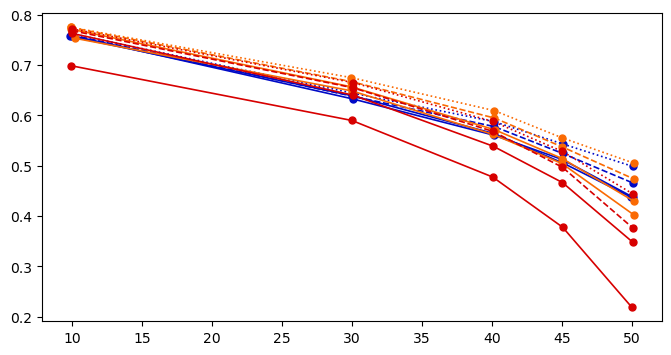

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))

for name, data in polardata_exp.items():
    i_values = data["I_LOAD"].to_numpy(dtype=float)
    v_values = data["VFC"].to_numpy(dtype=float) / n_cell
    idx_extracted = []
    for i_test in I_tested:
        idx_extracted.append(np.argmin((i_test - i_values) ** 2))
    plot_condition(ax, i_values[idx_extracted], v_values[idx_extracted], name, linewidth=1.2, markersize=5)

### Setup the simulation for all wanted conditions

In [6]:
def polartest_sim(model_calib):
    """Run the dynamic model across every (RHC, P, T) condition for which we
    have experimental data and return ``{cond_key: [Ucell at I_tested]}``.
    Returns ``False`` if any cell voltage came back NaN.

    Uses ``model_calib.parameters`` / ``model_calib.operating_inputs``
    consistently -- never the imported globals -- so concurrent trials with
    different parameters cannot race on the same dict.
    """
    OCV = model_calib.parameters["OCV"]
    Aact = model_calib.parameters["Aact"]
    op = model_calib.operating_inputs

    result = {}
    for RHC in RHC_tested:
        for P_des in PAC_tested:
            for T_des in TFC_tested:
                cond_key = "T" + str(T_des) + "_P" + str(int(P_des/1e2 - 1e3)) + "_HRC" + str(RHC)
                if cond_key not in polardata_exp:
                    continue
                op["Phi_c_des"] = RHC / 100
                op["Pa_des"] = P_des
                op["Pc_des"] = P_des
                op["Tfc"]    = T_des + 273.15

                Ucell_test = []
                for I_LOAD in I_tested:
                    # Default-arg captures the current density by value so the
                    # lambda is not tied to the loop variable I_LOAD.
                    i_density = I_LOAD / Aact
                    op["current_density"] = lambda t, _i=i_density: _i

                    x_init = init_x(op, model_calib.parameters)
                    sol = solve_ivp(model_calib.dxdt, (0, 60), x_init, method="BDF", max_step=1e-1)
                    last = {k: sol.y[idx, -1] for idx, k in enumerate(model_calib.solver_variable_names)}
                    Rmem_t, Rccl_t, Racl_t = Rproton(last, model_calib.parameters)
                    Rp = sum(Rmem_t) 
                    Ueq_t = Ueq(last)
                    Ucell_test.append(Ueq_t - OCV - i_density * (Rp + model_calib.parameters["Re"]) - last["eta_c"])
                    if any(math.isnan(v) for v in Ucell_test):
                        return False

                result[cond_key] = Ucell_test
    return result


In [7]:
def _experimental_ucell(cond_key):
    """Look up the experimental cell voltage at every I_tested for one
    operating condition. Picks the closest sample from the polar curve
    DataFrame and divides by ``n_cell`` (full-stack -> per-cell)."""
    df = polardata_exp[cond_key]
    i_exp = df["I_LOAD"].to_numpy(dtype=float)
    v_exp = df["VFC"].to_numpy(dtype=float) / n_cell
    idx = [np.argmin((i_test - i_exp) ** 2) for i_test in I_tested]
    return v_exp[idx]


def objective(trial):
    # Per-trial copies of the imported globals -- critical when
    # study.optimize uses n_jobs > 1, otherwise concurrent trials race
    # on the same `parameters` and `operating_inputs` dicts.
    params_trial = deepcopy(parameters)
    op_trial     = deepcopy(operating_inputs)

    params_trial["OCV"]          = trial.suggest_float("OCV",          0.2,   0.4,  log=True)
    params_trial["i0_c_ref"]     = trial.suggest_float("i0_c_ref",     1e-2,  10,   log=True)
    params_trial["kappa_c"]      = trial.suggest_float("kappa_c",      1,     10,   log=True)
    params_trial["tau"]          = trial.suggest_float("tau",          1,     4,    log=True)
    params_trial["Re"]           = trial.suggest_float("Re",           1e-7,  1e-5, log=True)
    params_trial["epsilon_mc"]   = trial.suggest_float("epsilon_mc",   0.15,  0.4,  log=True)
    params_trial["epsilon_gdl"]  = trial.suggest_float("epsilon_gdl",  0.5,   0.7,  log=True)
    params_trial["epsilon_c"]    = trial.suggest_float("epsilon_c",    0.1,   0.3,  log=True)
    params_trial["epsilon_cl"]   = trial.suggest_float("epsilon_cl",   0.1,   0.4,  log=True)
    params_trial["a_slim"]       = trial.suggest_float("a_slim",       1e-2,  0.5,  log=True)
    params_trial["b_slim"]       = trial.suggest_float("b_slim",       1e-2,  0.5,  log=True)
    params_trial["a_switch"]     = trial.suggest_float("a_switch",     1e-2,  0.5,  log=True)
    params_trial["Hcl"]          = trial.suggest_float("Hcl",          1e-5,  2e-5, log=True)
    params_trial["Hgdl"]         = trial.suggest_float("Hgdl",         2e-5,  5e-5, log=True)

    model_trial = PEMFC_dyn(params_trial, op_trial, init_x(op_trial, params_trial))

    try:
        polardata_sim = polartest_sim(model_trial)
    except Exception:
        return 100.0
    if polardata_sim is False:
        return 100.0

    # Sum of squared residuals across all conditions.
    error_sum = 0.0
    for cond_key, ucell_sim in polardata_sim.items():
        ucell_exp = _experimental_ucell(cond_key)
        error_sum += float(np.sum((np.array(ucell_sim) - ucell_exp) ** 2))

    return error_sum


## Sanity check
Dry-run the objective once with midpoint parameter values before starting the optimization. If `polartest_sim` returns a dict (not `False`) and the per-condition residuals are finite, the pipeline is wired correctly and `study.optimize` is safe to launch.


In [8]:
search_ranges = {
    "OCV":         (0.2,  0.4),
    "i0_c_ref":    (1e-2, 10),
    "kappa_c":     (1,    10),
    "tau":         (1,    4),
    "Re":          (1e-7, 1e-5),
    "epsilon_mc":  (0.15, 0.4),
    "epsilon_gdl": (0.5,  0.7),
    "epsilon_c":   (0.1,  0.3),
    "epsilon_cl":  (0.1,  0.4),
    "a_slim":      (1e-2, 0.5),
    "b_slim":      (1e-2, 0.5),
    "a_switch":    (1e-2, 0.5),
    "Hcl":         (1e-5, 2e-5),
    "Hgdl":        (2e-4, 5e-4),
}

params_chk = deepcopy(parameters)
op_chk     = deepcopy(operating_inputs)
for k, (lo, hi) in search_ranges.items():
    params_chk[k] = (lo * hi) ** 0.5  # midpoint on log scale

t0 = time.perf_counter()
sim = polartest_sim(PEMFC_dyn(params_chk, op_chk, init_x(op_chk, params_chk)))
elapsed = time.perf_counter() - t0

if sim is False:
    print(f"polartest_sim returned False after {elapsed:.1f}s "
          "-- NaN encountered during integration.")
else:
    total = 0.0
    print(f"polartest_sim ok in {elapsed:.1f}s")
    print(f"Per-condition residual (Σ(ΔU)² over {len(I_tested)} currents):")
    for cond_key, ucell_sim in sim.items():
        ucell_exp = _experimental_ucell(cond_key)
        sse = float(np.sum((np.array(ucell_sim) - ucell_exp) ** 2))
        total += sse
        print(f"  {cond_key:25s} -> {sse:.4f}")
    print(f"Total objective value = {total:.4f}")


polartest_sim ok in 353.8s
Per-condition residual (Σ(ΔU)² over 5 currents):
  T50_P300_HRC0             -> 0.3912
  T60_P300_HRC0             -> 0.2710
  T70_P300_HRC0             -> 0.2711
  T50_P300_HRC50            -> 0.3885
  T60_P300_HRC50            -> 0.2336
  T70_P300_HRC50            -> 0.1181
  T50_P400_HRC50            -> 0.3561
  T60_P400_HRC50            -> 0.1926
  T70_P400_HRC50            -> 0.0973
  T50_P500_HRC50            -> 0.3206
  T60_P500_HRC50            -> 0.1680
  T70_P500_HRC50            -> 0.0622
Total objective value = 2.8705


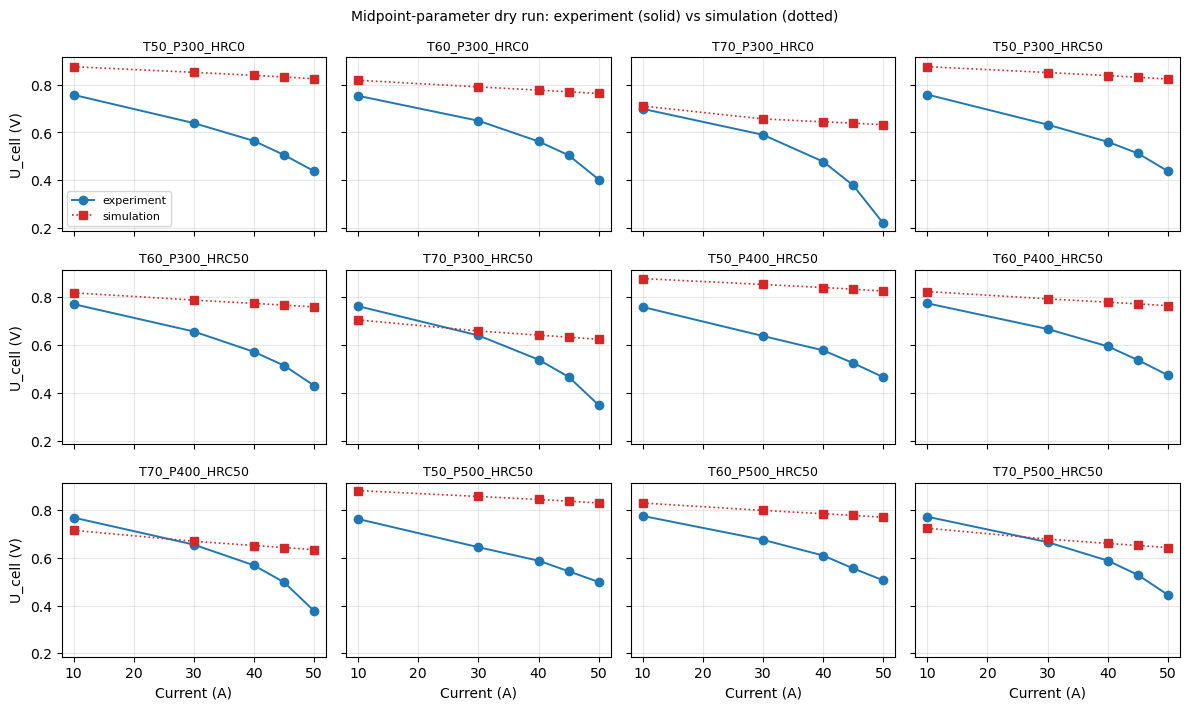

In [9]:
if sim is False:
    print("polartest_sim returned False -- nothing to plot.")
else:
    n = len(sim)
    ncols = 4
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 2.4 * nrows),
                             sharex=True, sharey=True, squeeze=False)
    for ax, (cond_key, ucell_sim) in zip(axes.flatten(), sim.items()):
        ucell_exp = _experimental_ucell(cond_key)
        ax.plot(I_tested, ucell_exp, "o-", color="tab:blue",
                linewidth=1.4, label="experiment")
        ax.plot(I_tested, ucell_sim, "s:", color="tab:red",
                linewidth=1.2, label="simulation")
        ax.set_title(cond_key, fontsize=9)
        ax.grid(True, alpha=0.3)
    for ax in axes.flatten()[n:]:
        ax.set_visible(False)
    for ax in axes[-1]:
        ax.set_xlabel("Current (A)")
    for ax in axes[:, 0]:
        ax.set_ylabel("U_cell (V)")
    axes.flatten()[0].legend(fontsize=8, loc="best")
    fig.suptitle("Midpoint-parameter dry run: experiment (solid) vs simulation (dotted)",
                 fontsize=10)
    fig.tight_layout()
    plt.show()


In [10]:
study = optuna.create_study(direction="minimize", pruner=MedianPruner())
study.optimize(objective, n_trials=1000, timeout=600, n_jobs=6)

print("Best parameters:", study.best_params)
print("Best objective:", study.best_value)


[I 2026-05-07 11:25:55,222] A new study created in memory with name: no-name-5b09d984-f8fd-4f53-ba27-98b244a7b8c4
[I 2026-05-07 11:58:44,835] Trial 3 finished with value: 1.8822203534341042 and parameters: {'OCV': 0.28753813313502813, 'i0_c_ref': 0.014223194913355755, 'kappa_c': 6.026510430822919, 'tau': 2.3580007331634794, 'Re': 3.3184701037945725e-06, 'epsilon_mc': 0.17641348080114927, 'epsilon_gdl': 0.550181123913446, 'epsilon_c': 0.15538386436748933, 'epsilon_cl': 0.1183585149344235, 'a_slim': 0.3555270229257564, 'b_slim': 0.10459822155223455, 'a_switch': 0.33786847609745446, 'Hcl': 1.0064102992973647e-05, 'Hgdl': 3.937663351360871e-05}. Best is trial 3 with value: 1.8822203534341042.
[I 2026-05-07 11:58:45,563] Trial 2 finished with value: 3.670780138061006 and parameters: {'OCV': 0.25145300454881503, 'i0_c_ref': 4.62073375035403, 'kappa_c': 2.0303681152220534, 'tau': 2.1089838206161406, 'Re': 1.0558982726984312e-06, 'epsilon_mc': 0.17760199762991122, 'epsilon_gdl': 0.572950914027

Best parameters: {'OCV': 0.38050753951547933, 'i0_c_ref': 0.6190699524347053, 'kappa_c': 4.195425785974712, 'tau': 1.0220098245352307, 'Re': 6.898678510280389e-07, 'epsilon_mc': 0.16367773128074456, 'epsilon_gdl': 0.561139559894394, 'epsilon_c': 0.23810444269714495, 'epsilon_cl': 0.20947000560356643, 'a_slim': 0.28969627853623947, 'b_slim': 0.02565228647530645, 'a_switch': 0.12821993481953023, 'Hcl': 1.8941755149287872e-05, 'Hgdl': 4.4537893665845004e-05}
Best objective: 1.2439736878806842


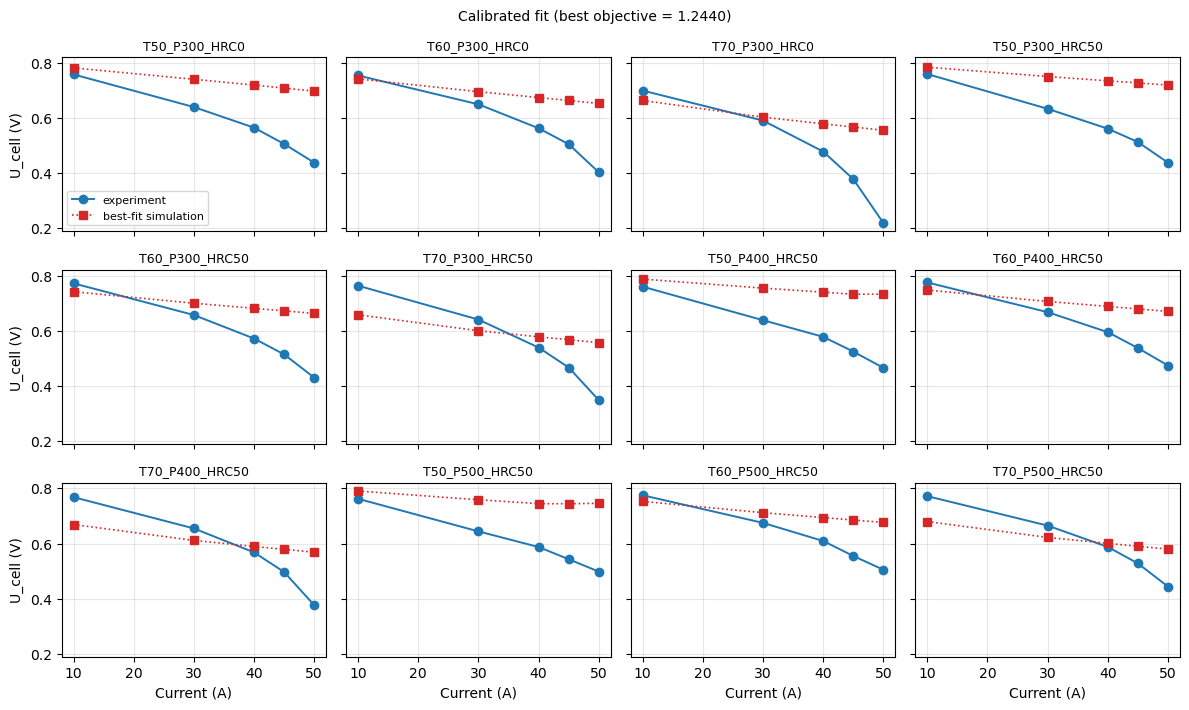

In [11]:
params_best = deepcopy(parameters)
op_best     = deepcopy(operating_inputs)
params_best.update(study.best_params)

model_best = PEMFC_dyn(params_best, op_best, init_x(op_best, params_best))
polardata_sim_best = polartest_sim(model_best)

if polardata_sim_best is False:
    print("polartest_sim returned False with the best parameters -- nothing to plot.")
else:
    n = len(polardata_sim_best)
    ncols = 4
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 2.4 * nrows),
                             sharex=True, sharey=True, squeeze=False)
    for ax, (cond_key, ucell_sim) in zip(axes.flatten(), polardata_sim_best.items()):
        ucell_exp = _experimental_ucell(cond_key)
        ax.plot(I_tested, ucell_exp, "o-", color="tab:blue",
                linewidth=1.4, label="experiment")
        ax.plot(I_tested, ucell_sim, "s:", color="tab:red",
                linewidth=1.2, label="best-fit simulation")
        ax.set_title(cond_key, fontsize=9)
        ax.grid(True, alpha=0.3)
    for ax in axes.flatten()[n:]:
        ax.set_visible(False)
    for ax in axes[-1]:
        ax.set_xlabel("Current (A)")
    for ax in axes[:, 0]:
        ax.set_ylabel("U_cell (V)")
    axes.flatten()[0].legend(fontsize=8, loc="best")
    fig.suptitle(f"Calibrated fit (best objective = {study.best_value:.4f})",
                 fontsize=10)
    fig.tight_layout()
    plt.show()
